# Transformada Discreta de Fourier e FFT



---

**Como entregar:** Enviar o seu jupyter notebook (.ipynb) pelo próprio Classroom. Uma cópia deste será automaticamente criada para você no seu Google Drive, você pode usar essa cópia mesmo, sem necessidade de criar outra.


**Leia com atenção:**


*   Você deve fazer obrigatoriamente todas as atividades marcadas com a exclamação❗.
*   Atividades marcadas com 🧩 são opcionais.
*   Use o Google Colab para executar o notebook e fazer a tarefa, ou baixe no seu computador e faça na API que preferir, mas lembre-se de entregar no Classroom a versão final.
*   A atividade vai ser baseada no seu número USP.
*   Há questões dissertativas!
*   Siga o passo a passo indicado no tutorial, respondendo as perguntas das atividades propostas no seu jupyter notebook.
*   O notebook que entregar deve estar 100% funcional, isto é, todos os códigos rodando no Colab sem erros.
*   Entregue o notebook completo, com todo conteúdo original e mais os seus códigos e textos.
*   Esta tarefa é individual e haverá controle de similaridade. Tentativas de cópias, fraude, compra-venda de EPs não serão toleradas, levando a nota zero na tarefa e posterior análise para medidas cabíveis.
*   ❗Exercício 00:❗ Para mostrar que você leu até aqui, escreva seu nome completo (assinatura) na linha a seguir:





* *texto em itálico*Assinatura:*Rodrigo Galvez Lima



---





## Pre-requisitos


Algumas referências usadas aqui, além dos livros textos do curso:

[1] https://pythonnumericalmethods.berkeley.edu/notebooks/chapter24.03-Fast-Fourier-Transform.html

[2] https://jakevdp.github.io/blog/2013/08/28/understanding-the-fft/

Primeiro vamos carregar algumas bibliotecas: Numpy, Scipy Linear Algebra (scipy.linalg), System (sys) e Time (time)

In [ ]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sys
import time

Agora vamos definir alguns números especiais ("magic") para cada aluno, com base no seu número USP

#### ❗Exercício 0❗

Preencha o seu número USP abaixo

In [ ]:
# Coloque aqui o seu número USP
nusp = 12553733

Estes números serão importantes para a atividade:

In [ ]:
nusp_str=str(nusp).replace("0","") #Remove o zero
nusp_str = "".join(dict.fromkeys(nusp_str)) #Remove duplicações

magic_ilong = int(nusp_str)
magic_ishort = int(str(magic_ilong)[:2])
magic_int1 = int(list(nusp_str)[-1])
magic_int2 = int(list(nusp_str)[-2])

print("magic_ilong  =", magic_ilong)
print("magic_ishort =", magic_ishort)
print("magic_int1 =", magic_int1)
print("magic_int2 =", magic_int2)



magic_ilong  = 12537
magic_ishort = 12
magic_int1 = 7
magic_int2 = 3




---




## Funções Periódicas e Análise de Fourier Contínua
Ao trabalharmos com funções periódicas, é muito conveniente usarmos funções complexas. As contas simplificam e é fácil deduzir os resultados para o caso real.

Considere então uma função

$$
  f: \mathbb{R} \to \mathbb{C}
$$

**periódica** de período $2\pi$. A ideia é decompô-la nas frequências associadas ao período usando as funções

$$
  f_k(x) = e^{ikx} = \cos kx + i\,\text{sen}\,kx,\quad k \in \mathbb{Z}.
$$

Cada uma delas tem período $2\pi/\vert k\vert$, e portanto também tem período $2\pi$ (o caso $k=0$ é para a função constante igual a $1$, que tem qualquer período). Quanto maior o valor de $\vert k\vert$, maior a frequência. Note que $k$ e $-k$ estão associados à mesma frequência, mas precisamos dos dois valores. As funções $e^{ikx}$ e $e^{-ikx}$ são linearmente independentes no espaço das funções complexas.

### Um Problema de Mínimos Quadrados
Dada a nossa função $2\pi$-periódica $f$, podemos formular o seguinte problema para aproximá-la: obtenha uma função da forma

$$
  g_M(x) = \sum_{k=-M}^M c_k e^{ikx}
$$

de modo a minimizar

$$
  \int_0^{2\pi} \vert f(x) - g_M(x) \vert^2\,dx,
$$

onde $M$ é um número natural positivo. Dizemos que $g_M$ é a aproximação para $f$ até o harmônico de ordem $M$. Note que, devido à periodicidade, toda informação relevante está contida em um intervalo de comprimento $2\pi$. Escolhemos $[0, 2\pi]$ por conveniência, mas qualquer outro intervalo de comprimento $2\pi$ serviria, e o resultado seria o mesmo.

Não é difícil concluir que $g_M$ é a solução de um problema de mínimos quadrados no espaço das funções periódocas de período $2\pi$ com o produto interno

$$
  \langle u, v \rangle = \int_0^{2\pi} u(x) \bar{v}(x)\,dx
$$

onde $\bar{v}(x)$ é o complexo conjugado de $v(x)$. Para $k \ne l$,

$$
  \langle f_k, f_l \rangle = \int_0^{2\pi} e^{i(l-k)x}\,dx = \left .\frac{e^{i(l-k)x}}{i(l-k)}\right\vert_0^{2\pi} = 0 \text{ (devido à periodicidade)}.
$$

Logo, as funções $f_k$ são ortogonais. Como $\langle f_k,f_k \rangle = 2\pi$, os coeficientes $c_k$ da aproximação $g_M$ são iguais a

$$
  c_k = \frac{1}{2\pi}\int_0^{2\pi} f(x)e^{-ikx}\,dx,\quad -M \le k \le M.
$$

### Funções Reais
Se $f$ for uma função real, os coeficientes são iguais a

$$
  c_k = \frac{1}{2\pi}\int_0^{2\pi}f(x)\cos kx\,dx - \frac{i}{2\pi}\int_0^{2\pi}f(x)\,\text{sen}\,kx\,dx = \alpha_k - i\beta_k,
$$

com $\alpha_k$ e $\beta_k$ reais. Uma consequência imediata é que $c_{-k} = \bar{c}_k$ e portanto

$$
  g_M(x) = \alpha_0 + 2\sum_{k=1}^M [\alpha_k\cos kx + \beta_k\,\text{sen}\,kx].
$$

Se usarmos a notação $a_k = 2\alpha_k$, $0\le k\le M$, e $b_k = 2\beta_k$, $1\le k\le M$, obtemos

$$
  g_M(x) = \frac{1}{2}a_0 + \sum_{k=1}^M [a_k\cos kx + b_k\,\text{sen}\,kx]
$$

com as expressões bem conhecidas

$$
  a_k = \frac{1}{\pi}\int_0^{2\pi} f(x)\cos kx\,dx,\quad 0\le k\le M,\\
  b_k = \frac{1}{\pi}\int_0^{2\pi} f(x)\,\text{sen}\,kx\,dx,\quad 1\le k\le M.
$$

Derivamos, portanto, a expansão de $f$ em sua série de Fourier!

## Análise de Fourier Discreta
O cálculo das integrais para a obtenção das aproximações é em geral feito com métodos de integração numérica, que serão estudados no curso. Estes métodos usam valores de funções em um conjunto discreto de pontos. Além diso, em processamento de sinais digitais, trabalhamos com valores discretos. Estes dois aspectos estão relacionados. Devido à importância do processamento de sinais digitais, discutiremos diretamente o caso de valores discretos, deixando para uma outra oportunidade a relação com integração numérica.

Considere uma função $f$ $2\pi$-periódica tabelada em $N$ pontos igulamente espaçados

$$
  x_j = j\frac{2\pi}{N},\quad 0 \le j \le N-1.
$$

Vamos aproximar $f$ por uma função $g_M$ da mesma forma que a usada acima,

$$
  g_M(x) = \sum_{k=-M}^M c'_ke^{ikx},
$$

mas agora de modo a minimizar a expressão

$$
  \sum_{j=0}^{N-1} \vert f(x_j) - g_M(x_j) \vert^2.
$$

Temos um problema de mínimos quadrados em relação ao produto interno

$$
  \langle u, v \rangle = \sum_{j=0}^{N-1} u(x_j)\overline{v(x_j)},
$$
onde $\overline{v(x_j)}$ é o complexo conjugado de $v(x_j)$. Mas, nos pontos discretos $x_j$, há informações que se repetem. Se $k$ e $l$ diferem por um multiplo inteiro de $N$, ou seja, $l = k + mN$ para algum $m\in\mathbb{Z}$, então

$$
  e^{ilx_j} = e^{ilj2\pi/N} = e^{i(k+mN)j2\pi/N} = e^{ikj2\pi/N}e^{imj2\pi} = e^{ikj2\pi/N} = e^{ikx_j}.
$$

Para valores restritos a $x_j$, $0\le j\le N-1$, temos periodicidade $N$ para cada $k$, logo devemos então restringir a quantidade de harmônicos. Específicamente, $2M < N$ ou

$$
  M \leq \frac{N}{2}
$$

(assumiremos daqui em diante que $N$ **é par**).

### Funções trigonométricas na prática

Vamos considerar $N$ pontos igualmente espaçados no intervalo $[0,2\pi]$,  dados por $x_j=2j\pi/N, j=0,1,..,N-1$, lembrando que vamos considerar **$N$ par**!!!

In [ ]:
# Tamanho da amostragem (número de pontos na série = N)
N = 64

# Pontos de amostragem x_j
x = np.arange(0, 2*np.pi, 2*np.pi/N)

Vamos montar algumas "ondas" (funções) e fazer algumas operações com elas.

In [ ]:
#Funções baseadas no número USP
def f1(x):
  return np.sin(magic_int1*x)

def f2(x):
  return np.sin(magic_int2*x)

def f3(x):
  return f1(x)+f2(x)

def f4(x):
  return f1(x)*f2(x)

Vejamos os gráficos dessas funções

Text(0.5, 0, 'x')

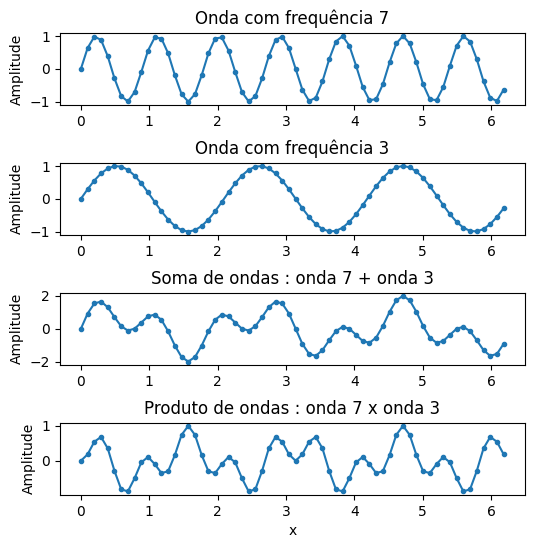

In [ ]:
# Amostrando as funções nos pontos x_j para gerar vetores
onda1 = f1(x)
onda2 = f2(x)
onda3 = f3(x)
onda4 = f4(x)

# Gráficos
figure, axs = plt.subplots(4, 1, figsize=(6,6))

plt.subplots_adjust(hspace=0.8)

axs[0].plot(x, onda1, marker=".")
axs[0].set_title("Onda com frequência "+str(magic_int1))
axs[0].set_ylabel("Amplitude")

axs[1].plot(x, onda2, marker=".")
axs[1].set_title("Onda com frequência "+str(magic_int2))
axs[1].set_ylabel("Amplitude")


axs[2].plot(x, onda1+onda2, marker=".")
axs[2].set_title("Soma de ondas : onda "+str(magic_int1)+" + onda "+str(magic_int2))
axs[2].set_ylabel("Amplitude")

axs[3].plot(x, onda1*onda2, marker=".")
axs[3].set_title("Produto de ondas : onda "+str(magic_int1)+" x onda "+str(magic_int2))
axs[3].set_ylabel("Amplitude")
axs[3].set_xlabel("x")

Usar funções de senos e cossenos pode ser bem trabalhoso e é conveniente usar a fórmula de Euler para trabalhar com funções trigonométricas:
$$
e^{ix}=\cos(x)+i\sin(x).
$$

Para cada harmônico ($k$), temos um vetor de $\mathbb{C}^n$, dado por
$$ v_k=[e^{ikx_j}]_{j=0,1,...N-1},$$
com $x_j=2j\pi/N$, $j=0,1,..,N-1$.
Considerando o produto interno complexo definido anteriormente
$$\langle u,v \rangle =\sum_{j=0}^{N-1}
u(x_j)\overline{v(x_j)},$$
com $x_j=2j\pi/N$, $j=0,1,..,N-1$, temos que os vetores $v_k$, $k=-N/2+1,..,N/2$, formam uma base ortogonal do $\mathbb{C}^{N}$. Isto é,

$$
\langle e^{ikx},e^{ilx} \rangle =0, \quad \text{se } l\neq k,
$$

para $l, k=-N/2+1,..,N/2$, e

$$ \langle e^{ikx},e^{ikx} \rangle = N.$$


#### 🧩 Atividade teórica 🧩
 Verifique teoricamente a ortonormalidade dos vetores $v_k=(e^{ikx_j})_j$ em relação a esse produto interno, conforme afirmado acima.

 Conclua que, portanto, valem as seguintes relações de ortogonalidade:
*   $\langle \sin(kx), \sin(lx) \rangle = 0$ se $k\neq l$,
*   $\langle \cos(kx), \cos(lx) \rangle = 0$ se $k\neq l$,
*   $\langle \sin(kx), \cos(lx) \rangle = 0$ .
*   $\langle \sin(kx), \sin(lx) \rangle = N/2$ .





#### ❗Exercício 1 ❗

Faça um código em Python que recebe duas funções (como as funções f1, f2, f3, f4 implementadas acima) e calcula esse produto interno de uma discretização delas, para um dado valor de $N$, usando pontos uniformemente espaçados em $[0,2\pi]$. Com base neste código, verifique os valores de


1.   $\|\sin(3x)\|^2 =  \langle \sin(3x), \sin(3x) \rangle$
2.   $\|\sin(10x)\|^2 =  \langle \sin(10x), \sin(10x) \rangle$
3.   $ \langle \sin(3x), \sin(10x) \rangle$
4.   $ \langle \sin(3x)+\sin(10x), \sin(3x)+\sin(10x) \rangle$
5.   $ \langle \sin(3x)\sin(10x), \sin(3x) \rangle$

Justifique os resultados encontrados. Use $N=64$ nas contas (os valores mudam se aumentar/diminuir o $N$?).

*OBS:* Se quiser, pode fazer o produto interno para funções reais apenas (sem necessidade de usar complexos)!

In [ ]:
# Tamanho da amostragem (número de pontos na série = N)
N = 64

# Pontos de amostragem x_j
x = np.arange(0, 2*np.pi, 2*np.pi/N)

#Códigos
y1 = f1(x)
y2 = f2(x)
y3 = f3(x)
y4 = f4(x)
produto_interno= np.sum(y1*y2)
print(produto_interno)




-2.275957200481571e-15


In [ ]:
# Aplicação de exercício
def f5(x):
  return np.sin(3*x)
def f6(x):
  return np.sin(10*x)
def f7(x):
  return np.sin(3*x) + np.sin(10*x)
def f8(x):
  return np.sin(10*x)*np.sin(3*x)
#1:
produto_1= np.sum(f5(x)*f5(x))
print("⟨sin(3x),sin(3x)⟩",produto_1)
#2:
produto_2= np.sum(f6(x)*f6(x))
print("⟨sin(10x),sin(10x)⟩",produto_2)
#3:
produto_3= np.sum(f5(x)*f6(x))
print("⟨sin(3x),sin(10x)⟩",produto_3)
#4:
produto_4= np.sum(f7(x)*f7(x))
print("⟨sin(3x)+sin(10x),sin(3x)+sin(10x)⟩",produto_4)
#5:
produto_5= np.sum(f8(x)*f5(x))
print("⟨sin(3x)sin(10x),sin(3x)⟩",produto_5)






⟨sin(3x),sin(3x)⟩ 32.000000000000014
⟨sin(10x),sin(10x)⟩ 32.000000000000014
⟨sin(3x),sin(10x)⟩ -4.912736883966318e-15
⟨sin(3x)+sin(10x),sin(3x)+sin(10x)⟩ 64.00000000000003
⟨sin(3x)sin(10x),sin(3x)⟩ 3.552713678800501e-15


Justificativas:
1.  Como ⟨eikx,eikx⟩=N , colocando sen na forma de euler e colocando no produto interno o Produto interno será aproximadamente N/2, não exatamente por conta da discretização e aproximação do computador. Portanto 64/2 = 32
2.Igual ao 1
3.  ⟨eikx,eilx⟩=0,se l≠k, por conta da ortogonalidade deu aproximadamente 0 já que os coeficientes são diferentes.
4.  expandindo ficará ⟨sin(3x)+sin(10x),sin(3x)+sin(10x)⟩=⟨sin(3x),sin(3x)⟩+⟨sin(3x),sin(10x)⟩+⟨sin(10x),sin(3x)⟩+⟨sin(10x),sin(10x)⟩
5.  igual ao 3



---



### A Transformada Discreta de Fourier

Para o caso da nossa aproximação $g_M$,

$$
  g_M(x) = \sum_{k=-M}^M c'_ke^{ikx},
$$
concluímos que os vetores $v_k = [e^{ikx_j}]$, $-M \le k \le M$, com $M<N/2$, são ortogonais e satisfazem

$$
  \langle e^{ikx}, e^{ilx} \rangle =
  \left\{\begin{array}{rl}
  N, & \text{se } k=l,\\
  0, & \text{se } k \ne l.
  \end{array} \right .
$$

Logo, os coeficientes de $g_M(x)$ são dados por
$$
  c'_k = \frac{\langle f(x), e^{ikx}\rangle }{\langle e^{ikx}, e^{ikx}\rangle }= \frac{1}{N}\sum_{j=0}^{N-1}f(x_j)e^{-ikj2\pi/N},\quad -M \le k \le M.
$$

Um caso importante consiste em incluir $k=N/2$ na aproximação. Mas não podemos usar $k=-N/2$ pois teríamos os mesmos valores que no caso $N/2$ ($v_{N/2}=v_{-N/2}$, verifique!). A aproximação, que por um abuso de notação chamaremos de $g_{\frac{N}{2}}$, tem a forma

$$
  g_{\frac{N}{2}}(x) = \sum_{k=-\frac{N}{2}+1}^{\frac{N}{2}}c'_ke^{ikx}.
$$

As relações de ortogonalidade continuam válidas e a solução do problema de mínimos quadrados tem os coeficientes iguais a

$$
  c'_k = \frac{1}{N}\sum_{j=0}^{N-1}F_je^{-ikj2\pi/N},\quad -\frac{N}{2}+1 \le k \le \frac{N}{2},
$$

onde $F_j = f(x_j)$. Mas agora há algo novo. O **erro quadrático é igual a** $0$. Ou seja $g_{\frac{N}{2}}$ é um **polinômio trigonométrico interpolador**: $g_{\frac{N}{2}}(x_j) = F_j$, $0 \le j \le N-1$. Ou seja,

$$
  F_j = \sum_{k=-\frac{N}{2}+1}^{\frac{N}{2}}c'_ke^{ikj2\pi/N},\quad 0 \le j \le N-1.
$$

Dizemos que os $N$ números complexos $\{c'_k\}_{k=-\frac{N}{2}+1}^{\frac{N}{2}}$ são a **transformada discreta de Fourier** dos $N$ números complexos $\{F_j\}_{j=0}^{N-1}$ e que estes últimos são a transformada discreta de Fourier **inversa** dos primeiros.



---



### Período Arbitrário

Considere agora uma função

$$
  f: \mathbb{R} \to \mathbb{C}
$$

periódica de período $T > 0$. Aproximaremos $f$ pelas funções

$$
  f_k(x) = e^{ik\frac{2\pi}{T}x},
$$

que têm período $T$. Os pontos discretos são agora

$$
  x_j = j\frac{T}{N},\quad 0\le j\le N-1.
$$

Como

$$
  f_k(x_j) = e^{ik\frac{2\pi}{T}j\frac{T}{N}} = e^{ikj2\pi/N},
$$

as contas são as mesmas, interpretando-se corretamente $F_j = f(jT/N)$, $0\le j\le N-1$.



---



### Caso Real

No caso em que $F$ é uma função real, os coeficientes $c'_k$ e $c'_{-k}$ são complexos conjugados
$$c'_k=\alpha_k+i\beta_k$$
$$c'_{-k}=\overline{c'_k}=
\alpha_k-i\beta_k$$
de tal forma que
\begin{equation}
	c'_{-k}e^{-ikx_j}+c'_k e^{ikx_j} = 2(\alpha_k \cos(kx_j)-\beta_k\sin(kx_j))
\end{equation}
representa **o harmônico de ordem $k$ de $f(x)$**, com amplitude $A_k=2\sqrt{\alpha_k^2
+\beta_k^2}=2|c'_k|$, $k=1, 2, ..., N/2-1$.

Os coeficientes $c'_0$ e $c'_{N/2}$ têm parte imaginária nula quando $F$ é real.
O coeficiente $c'_0$ é simplesmente a média da função. O coeficiente $c'_{N/2}$ indica a quantidade de energia na maior frequência representável por esse conjunto de $N$ pontos, frequência conhecida como frequência de Nyquist ($N/2$ ciclos por unidade de tempo, dado pelo período $T$ do sinal).





---



---




### Resumindo


Note que, pela periodicidade das funções trigonométricas, temos que

\begin{equation}
e^{-ikx_j}=e^{-2ikj\pi/N}=e^{2i\pi j}e^{-2ikj\pi/N}=e^{2i(N-k)j\pi/N}=e^{i(N-k)x_j},
\end{equation}

e portanto podemos alternativamente escrever as transformadas (inversa e direta) como
\begin{equation}
	F_j = \sum_{k=0}^{N-1}c_k e^{ikx_j}\ \ ,j=0,..,N-1, \quad \text{(IDFT)}
\end{equation}
e
\begin{equation}
        c_k=\frac{1}{N} \sum_{j=0}^{N-1} F_je^{-ikx_j} , \ \ k=0,...,N-1, \quad \text{(DFT)}
\end{equation}
onde (IDFT) indica *Inverse Discrete Fourier Transform* e (DFT) indica *Discrete Fourier Transform* e consideramos $c_k=c'_k$, $k=0,1,..,\frac{N}{2}$ e $c_{N-k}=c'_{-k}, k=1,...,\frac{N}{2}-1$.



---



---





Vejamos abaixo uma implementação da transformada discreta de Fourier e de sua inversa:

In [ ]:
# Códigos

def dft(F):
  N = int(len(F))        #Tamanho do vetor
  n = np.arange(N)       # 0,1,....N-1
  x = (2*np.pi/N)*n      # pontos de amostragem x_i
  k = n.reshape((N, 1))  # frequências
  e = np.exp(-1j*k*x)    # exp(-i k x)
  c = np.dot(F, e)/(N)  # Transformada
  return c

def idft(c):
  N = int(len(c))        #tamanho do vetor
  n = np.arange(N)       # 0,1,....N-1
  x = (2*np.pi/N)*n      # pontos de amostragem x_i
  k = n.reshape((N, 1))  # frequencias
  e = np.exp(1j*k*x)     # exp(i k x)
  F = np.dot(c, e) # Transformada inversa
  return F.real

Nas bibliotecas, a divisão por N fica na IDFT e não na DFT, veremos isso mais adiante.

#### ❗Exercício 2 ❗

Teste a implementação usando as funções f1, f2, f3, f4, considerando N=16 pontos:
  1.    Verifique se a aplicação da transformada seguida da inversa recupera a função original.
  2.    Faça gráficos das amplitudes dos coeficientes da transformada (com $k=0,1, ...,N-1$ no eixo $x$ e as amplitudes $|c_k|$ no eixo $y$) e verifique se a transformada capturou corretamente os números de onda (frequências de oscilação) em cada caso.

📚 Observe o que aconteceu com as frequências no caso de soma e produto de funções trigonométricas.

📚 Observe como se dá a ordem dos coeficientes $c_k$, e que simetria possuem.

Sugestão: Ao fazer o gráfico dos coeficientes, use um gráfico do tipo "stem": https://matplotlib.org/stable/gallery/lines_bars_and_markers/stem_plot.html#sphx-glr-gallery-lines-bars-and-markers-stem-plot-py




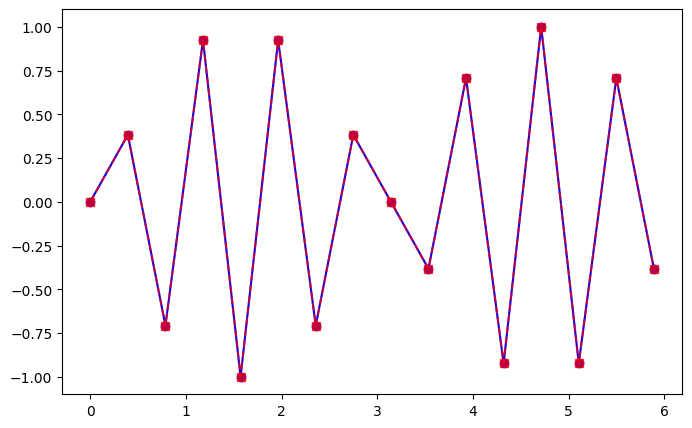

In [ ]:
# Códigos:
# Tamanho da amostragem (número de pontos na série = N)
N = 16

# Pontos de amostragem x_j
x = np.arange(0, 2*np.pi, 2*np.pi/N)

#Funções baseadas no número USP
def f1(x):
  return np.sin(magic_int1*x)

def f2(x):
  return np.sin(magic_int2*x)

def f3(x):
  return f1(x)+f2(x)

def f4(x):
  return f1(x)*f2(x)

 # Amostrando as funções nos pontos x_j para gerar vetores
onda1 = f1(x)
onda2 = f2(x)
onda3 = f3(x)
onda4 = f4(x)

f1= dft(onda1)
f2= dft(onda2)
f3= dft(onda3)
f4= dft(onda4)

#inversas:
inversa1=idft(f1)
inversa2=idft(f2)
inversa3=idft(f3)
inversa4=idft(f4)

plt.figure(figsize=(8, 5))  # Define o tamanho do gráfico
plt.plot(x, onda1, marker='o', linestyle='-', color='b', label="Onda 1")  # Onda original
plt.plot(x, inversa1, marker='s', linestyle='--', color='r', alpha=0.7, label="Inversa 1")  # Onda reconstruída


#como é possível perceber os gráficos são indenticos

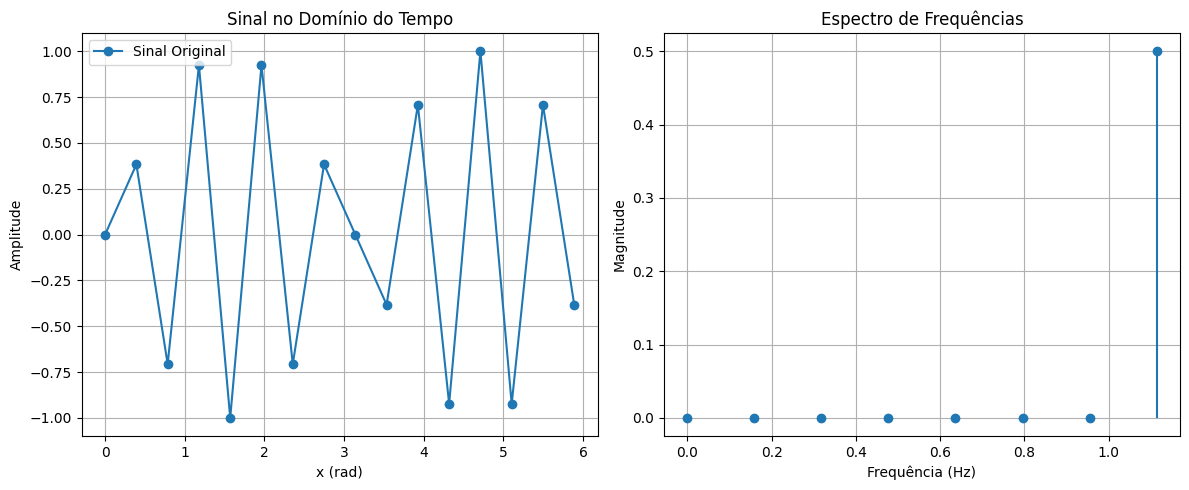

In [ ]:
# gráfico com onda 1
C = dft(onda1)

# Criar o eixo de frequências
frequencias = np.fft.fftfreq(N, d=(2*np.pi/N))

# Plotar o sinal original
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, onda1, marker='o', label="Sinal Original")
plt.xlabel("x (rad)")
plt.ylabel("Amplitude")
plt.title("Sinal no Domínio do Tempo")
plt.legend()
plt.grid()

# Plotar o módulo da Transformada de Fourier
plt.subplot(1, 2, 2)
plt.stem(frequencias[:N // 2], np.abs(C[:N // 2]), basefmt=" ")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Espectro de Frequências")
plt.grid()

plt.tight_layout()

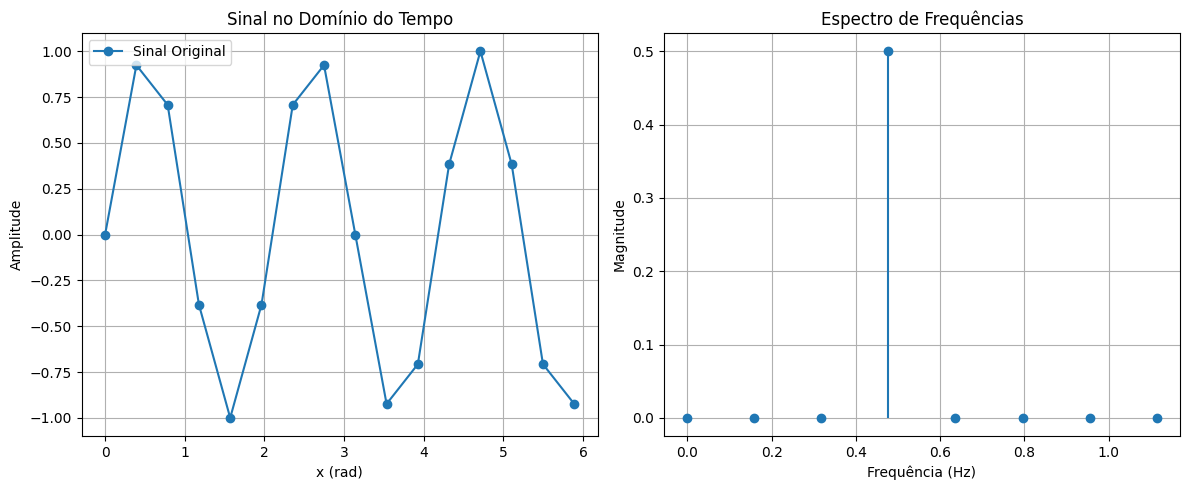

In [ ]:
# gráfico com onda 2
C = dft(onda2)

# Criar o eixo de frequências
frequencias = np.fft.fftfreq(N, d=(2*np.pi/N))

# Plotar o sinal original
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, onda2, marker='o', label="Sinal Original")
plt.xlabel("x (rad)")
plt.ylabel("Amplitude")
plt.title("Sinal no Domínio do Tempo")
plt.legend()
plt.grid()

# Plotar o módulo da Transformada de Fourier
plt.subplot(1, 2, 2)
plt.stem(frequencias[:N // 2], np.abs(C[:N // 2]), basefmt=" ")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Espectro de Frequências")
plt.grid()

plt.tight_layout()


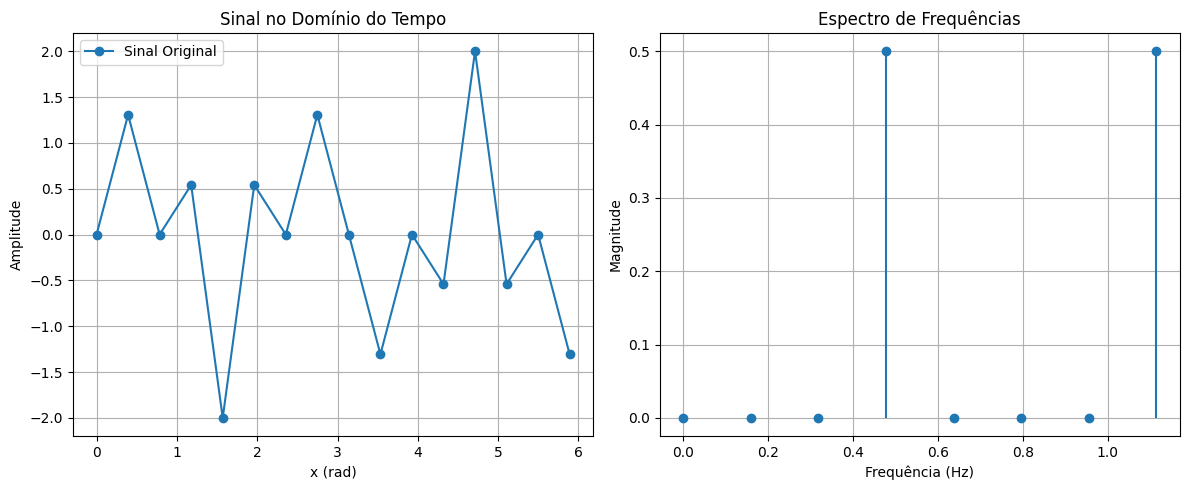

In [ ]:
# gráfico com onda 3
C = dft(onda3)

# Criar o eixo de frequências
frequencias = np.fft.fftfreq(N, d=(2*np.pi/N))

# Plotar o sinal original
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, onda3, marker='o', label="Sinal Original")
plt.xlabel("x (rad)")
plt.ylabel("Amplitude")
plt.title("Sinal no Domínio do Tempo")
plt.legend()
plt.grid()

# Plotar o módulo da Transformada de Fourier
plt.subplot(1, 2, 2)
plt.stem(frequencias[:N // 2], np.abs(C[:N // 2]), basefmt=" ")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Espectro de Frequências")
plt.grid()

plt.tight_layout()


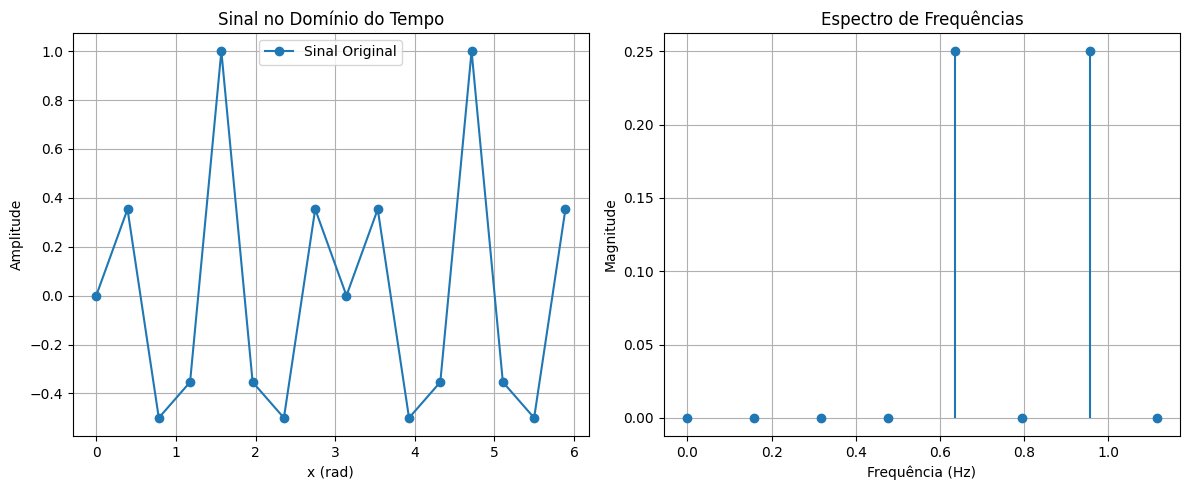

In [ ]:
# gráfico com onda 4
C = dft(onda4)

# Criar o eixo de frequências
frequencias = np.fft.fftfreq(N, d=(2*np.pi/N))

# Plotar o sinal original
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, onda4, marker='o', label="Sinal Original")
plt.xlabel("x (rad)")
plt.ylabel("Amplitude")
plt.title("Sinal no Domínio do Tempo")
plt.legend()
plt.grid()

# Plotar o módulo da Transformada de Fourier
plt.subplot(1, 2, 2)
plt.stem(frequencias[:N // 2], np.abs(C[:N // 2]), basefmt=" ")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Espectro de Frequências")
plt.grid()

plt.tight_layout()

Comentários:



---



### Eficiência computacional




Analisando a complexidade computacional da transformada de Fourier discreta (DFT) nota-se que temos que calcular $N$ coeficientes (os $c_k$) e para cada um deles temos um somatório com $N$ termos. Logo, o número de operações de arimética de ponto flutuante será da ordem de $O(N^2)$.



#### ❗Exercício 3 ❗

Considere a função
$$f(x) = e^{-5 (x-\pi)^2}, \quad x\in [0,2\pi]. $$

1.  Calcule a transformada discreta de Fourier usando $N=2^8=256$ e faça um gráfico da amplitude dos coeficientes $c_k$. Avalie quanto tempo demorou a execução (pode usar a função time.time() ou %timeit para contar tempo de execução)
2.  Avalie o tempo de execução para $N=2^m$ com $m=8, 9, 10, 11, 12, 13, 14, 15$. Faça uma tabela dos valores de $N$ em relação aos tempos de execução e verifique que, apesar de estamos apenas duplicando o número pontos amostrados, o tempo de execução cresce aproximadamente por 4 quando aumentamos em uma unidade o $m$ (duplicamos o número de pontos amostrados).

OBS: As vezes o tempo de uma única execução de um código pode sofrer efeitos pontuais de algo que está rodando no sistema. Para ter uma noção mais precisa do custo computacional, geralmente executamos algumas vezes o mesmo código e tomamos a média dos tempos de execução para ter o tempo médio de execução.

tempo: 0.0071752071380615234


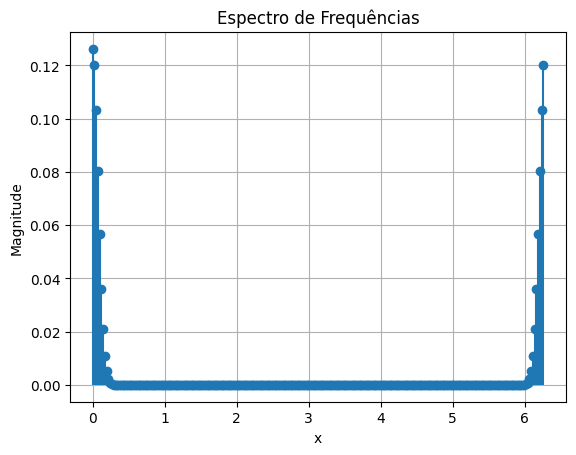

In [ ]:
# Código
# Tamanho da amostragem (número de pontos na série = N)
m = 8
N = 2**m

# Pontos de amostragem x_j
x = np.arange(0, 2*np.pi, 2*np.pi/N)

f = np.exp(-5*(x-np.pi)**2)
t0=time.time() #tempo inicial
Fourier = dft(f)
tf=time.time() #tempo final
print("tempo:",tf-t0)
plt.stem(x, np.abs(Fourier), basefmt=" ")
plt.xlabel("x")
plt.ylabel("Magnitude")
plt.title("Espectro de Frequências")
plt.grid()





In [ ]:
#tempos


vt = np.array([])  #vetor dos tempos

# Laço for correto
for m in range(8, 16):
  N = 2**m
  x = np.arange(0, 2*np.pi, 2*np.pi/N)
  f = np.exp(-5*(x-np.pi)**2)
  t0 = time.time()
  Fourier = dft(f)
  tf = time.time()
  tempo = tf - t0
  vt = np.append(vt, tempo)

dif1 = vt[1]/ vt[0]
dif2 = vt[7]/ vt[6]
print(vt)
print("dif1=",dif1, "dif2=", dif2)
#print("dif1:",dif1,"dif2:",dif2)

In [ ]:
#tabela
# Organizar os dados no formato de tabela
colunas = ["m", "tempo de execução"]
m=[8,9,10,11,12,13,14,15]
dados = np.column_stack((m, vt))  # Une os vetores em colunas

# Criar a figura e os eixos
fig, ax = plt.subplots()

# Ocultar os eixos para mostrar apenas a tabela
ax.axis("tight")
ax.axis("off")

# Criar a tabela
tabela = ax.table(cellText=dados, colLabels=colunas, cellLoc="center", loc="center")

# Exibir a tabela
plt.show()


Comentários:



---






### Transformada Rápida de Fourier (FFT)

Note que há muitas operações iguais que são feitas ao calcularmos diferentes coeficientes. Por exemplo $e^{2\pi k j / N} = e^{2\pi 3 / N}$ é calculado quando temos $k=1$ e $j=3$, mas também quando $k=3$ e $j=1$.

É possível aproveitar algumas simetrias dessas contas e reduzir o número de operações para algo da ordem de $O(N\log(N))$. Isso é conhecido como **Transformada Rápida de Fourier** (FFT - Fast Fourier Transform).

Um dos algoritmos mais conhecidos de transformada rápida de Fourier é o algoritmo de Cooley & Tukey (Cooley, James W.; Tukey, John W. (1965), An algorithm for the machine calculation of complex Fourier series, Math. Comput. 19, 297-301). A ideia central do algoritmo é dividir a transformação em pedaços menores (na metade por exemplo, considerando os pares e os ímpares), e realizar transformadas nesses subconjuntos, recursivamente.

A efetividade do algoritmo depende de $N$ ser fatorável em fatores primos pequenos. Vamos aqui nos restringir ao caso em $N$ é uma potência de $2$, embora haja diversas implementações muito eficientes para transformadas de comprimento do tipo $2^l3^m5^n7^p$.

Vejamos um exemplo de implementação ingênua, recursiva, de FFT. A única ressalva, comparado ao nosso algoritmo original de DFT, é que este precisa que a entrada seja um vetor com **$N$ potência de $2$**, e ao final da execução completa, precisamos **dividir os coeficientes por $N$** para obter o análogo ao DFT anterior.


In [ ]:
# FFT de Cooley-Tukey
def fft(x):
    N = len(x)

    if N == 1:
        return x
    else:
        pares = fft(x[::2])
        impares = fft(x[1::2])
        exp = np.exp(-2j*np.pi*np.arange(N)/ N)

        c = np.concatenate([pares+exp[:int(N/2)]*impares, pares+exp[int(N/2):]*impares])
        return c

Para entendermos a ideia da recurssão acima, considere a DFT de $N$ pontos
$$
  c_k = \sum_{j=0}^{N-1} f_jw_N^{jk},\quad 0 \le k \le N-1,
$$
onde $w_N = e^{i2\pi/N}$. Podemos separar a somatória em índices pares e ímpares:
$$
  c_k = \sum_{j=o}^{\frac{N}{2}-1} f_{2j}w_{\frac{N}{2}}^{jk} + w_N^k\sum_{j=0}^{\frac{N}{2}-1} f_{2j+1}w_{\frac{N}{2}}^{jk}, \quad 0 \le k \le N-1.
$$
Logo, se definirmos as DFTs de $N/2$ pontos
$$
  c_k^{(0)} = \sum_{j=o}^{\frac{N}{2}-1} f_{2j}w_{\frac{N}{2}}^{jk}\\
  c_k^{(1)} = \sum_{j=0}^{\frac{N}{2}-1} f_{2j+1}w_{\frac{N}{2}}^{jk}
$$
para $0 \le k \le N/2 -1$, obtemos
$$
  c_k = c_k^{(0)} + w_N^kc_k^{(1)},\\
  c_{k+N/2} = c_k^{(0)} - w_N^kc_k^{(1)},
$$
$0 \le k \le N/2-1$. Ou seja, o cálculo de uma DFT de $N$ pontos foi reduzido ao cálculo de duas DFTs de $N/2$ pontos com o uso de $N$ adições/subtrações e $N/2$ multiplicações.

O processo agora pode ser repetido recursivamente: $c_k^{(0)}$ pode ser obtido de duas DFTs de $N/4$ pontos $c_k^{(00)}$ e $c_k^{(01)}$, e $c_k^{(1)}$ pode ser obtido de duas DFTs de $N/4$ pontos $c_k^{(10)}$ e $c_k^{(11)}$, envolvendo novamente um total de $N$ adições/subtrações e $N/2$ multiplicações, etc. Após $\log_2(N)$ etapas chegamos a $N$ DFTs de tamanho 1, quando o processo termina.

Desta forma, uma DFT de $N$ pontos pode ser calculada com um número de operações aritméticas da ordem de $N\log_2(N)$. Compare com $N^2$, caso fizéssemos as contas de forma ingênua.

#### ❗Exercício 4 ❗


1. Verifique que a FFT está dando o mesmo resultado que a transformada discreta de Fourier (DFT). Para tanto, faça o gráfico do espectro (amplitudes) do DFT e do FFT e calcule a diferença entre eles (faça um gráfico da diferença). Verifique se essa diferença está pequena (apenas erros de aritmética de ponto flutuante).

2. Repita o procedimento do exemplo anterior de análise de custo computacional, mas agora usando a transformada rápida implementada. Verifique e comente a respeito do aumento do tempo de execução quando aumentamos o número de pontos amostrados. Mostre os resultados na forma de uma tabela.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

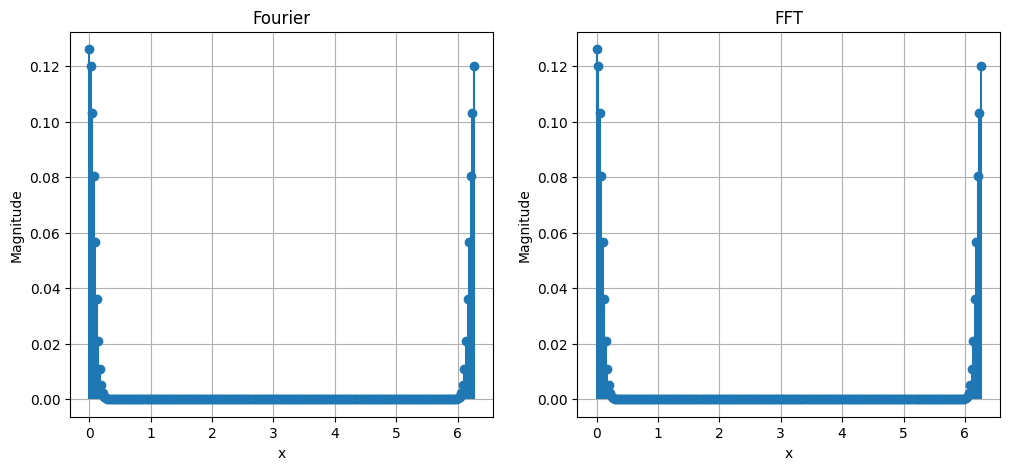

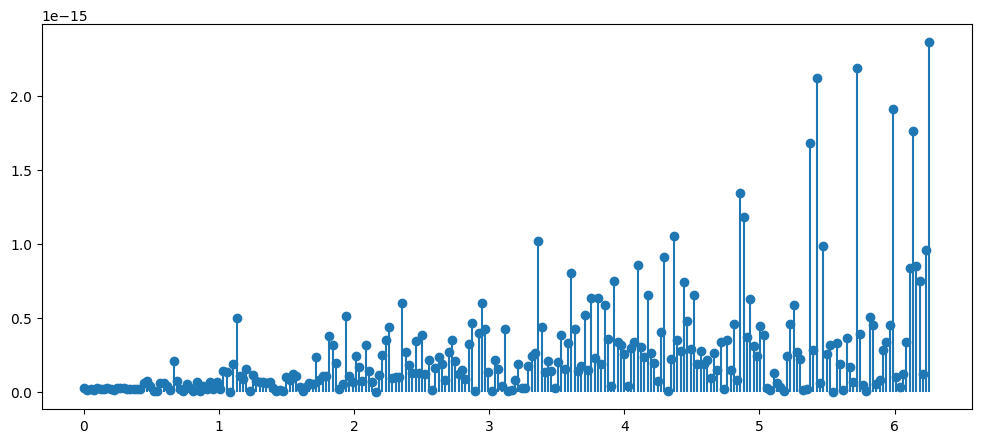

In [ ]:
# Código 1 mostrar que é mais rápido
# Tamanho da amostragem (número de pontos na série = N)
m = 8
N = 2**m

# Pontos de amostragem x_j
x = np.arange(0, 2*np.pi, 2*np.pi/N)

f = np.exp(-5*(x-np.pi)**2)
#t0=time.time() #tempo inicial
Fourier = dft(f)
FastFourier = fft(f)/N

#tf=time.time() #tempo final
#print("tempo:",tf-t0)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.stem(x, np.abs(Fourier), basefmt=" ")
plt.xlabel("x")
plt.ylabel("Magnitude")
plt.title("Fourier")
plt.grid()


plt.subplot(1, 2, 2)
plt.stem(x, np.abs(FastFourier), basefmt=" ")
plt.xlabel("x")
plt.ylabel("Magnitude")
plt.title("FFT")
plt.grid()

#DIferennça
Diferença=Fourier-FastFourier
plt.figure(figsize=(12, 5))
plt.stem(x, np.abs(Diferença), basefmt=" ")
plt





In [ ]:
# Código 2
#tempos


vt = np.array([])  #vetor dos tempos

# Laço for correto
for m in range(8, 16):
  N = 2**m
  x = np.arange(0, 2*np.pi, 2*np.pi/N)
  f = np.exp(-5*(x-np.pi)**2)
  t0 = time.time()
  FastFourier = fft(f)/N
  tf = time.time()
  tempo = tf - t0
  vt = np.append(vt, tempo)

dif1 = vt[1]/ vt[0]
dif2 = vt[7]/ vt[6]
print(vt)
print("dif1=",dif1, "dif2=", dif2)



[0.00689483 0.00489879 0.00906634 0.0200305  0.03782678 0.07675266
 0.15241289 0.73755646]
dif1= 0.7105017462567862 dif2= 4.839199957451202


Comentários:



---



A transformada rápida de Fourier (FFT) tem implementações no pacote Numpy e Scipy. A transfomação feita as vezes varia de implementação para implementação, geralmente por um fator que depende de $N$, por isso, é importante conhecer o que está por trás da implementação:

https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html

https://docs.scipy.org/doc/scipy/tutorial/fft.html

Note que precisamos dividir por $N$ para termos resultados comparáveis a nossa DFT. A diferença aqui é simplesmente pois nos pacotes o fator $1/N$ é colocado na tranformada inversa, e não na direta, por conveniência computacional.



#### 🧩 Atividade opcional 🧩

Verifique agora o tempo de execução de todos esses métodos que foram expostos (DFT, FFT, numpy.fft, scipy.fft). É natural de se esperar que os métodos das bibliotecas fiquem mais rápidos, pois são funções pre-compiladas, mas é importante verificar que elas também tem complexidade computacional de $O(N\log(N))$, como a nossa FFT.





---

